In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

,filename,code
2,./nbody.wast,1120
3,./spectral-norm.wast,770
4,./fankuchredux.wast,545
5,./mandelbrot.wast,525
6,./reverse-complement.wast,314
7,./fasta.wast,294
8,./binarytrees.wast,255


,code
count,7.000000
mean,546.142857
std,311.475750
min,255.000000
25%,304.000000
50%,525.000000
75%,657.500000
max,1120.000000


525.0

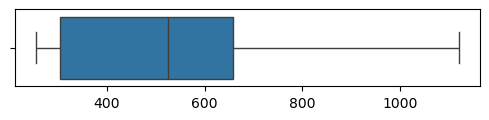

In [2]:
df = pd.read_csv("sturdy-wasm/src/test/resources/sturdy/language/wasm/benchmarksgame/src/loc.csv")
df = df[['filename', 'code']]
df = df[(df['filename'] != './k-nucleotide.wast') & (df['filename'] != './pidigits.wast')]
display(df)
display(df.describe())
display(df['code'].median())

fig, ax = plt.subplots(figsize=(6, 1))
sns.boxplot(df, x = 'code',  ax=ax).set(xlabel=None)
plt.savefig("benchmarksgame_loc.png",  bbox_inches="tight", dpi=300)

In [5]:
df = pd.read_csv("benchmarks-game-performance-test.csv")
df['time'] = df['time'] / 1e9
df['byte_size'] = df['byte_size'] / 1e3
df['program'] = df['program'].map(lambda program: program.replace(".wasm", ""))
df['analysis'] = df['analysis'].map({'Polka': 'Polyhedra', 'Octagon': 'Octagons', 'Box': 'Intervals'})

df.groupby(by=['analysis'])[['analysis','time']].describe()

time                                                      \
          count       mean        std       min       25%       50%   
analysis                                                              
Intervals  35.0   1.355823   1.198059  0.158485  0.350193  0.868818   
Octagons   35.0  13.514923  23.015172  0.288333  0.544276  0.909104   
Polyhedra  35.0  22.023005  25.246452  0.799473  1.586367  8.175959   

                                 
                 75%        max  
analysis                         
Intervals   2.481046   3.508062  
Octagons   24.483642  65.468529  
Polyhedra  51.407342  68.138474

/tmp/ipykernel_67257/2930031155.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


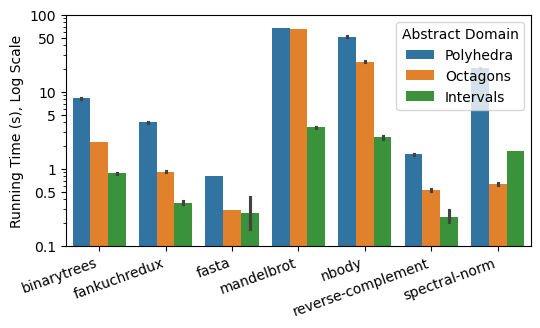

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(df, x = 'program', y = 'time', hue = 'analysis', ax=ax)
ax.set(yscale='log')
ax.set_yticks([0.1,0.5,1,5,10,50,100], labels=["0.1","0.5","1","5", "10","50","100"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_xlabel(None)
ax.set_ylabel("Running Time (s), Log Scale")
ax.legend_.set_title("Abstract Domain")
plt.savefig("benchmarksgame_running_time_per_program.png",  bbox_inches="tight", dpi=300)

In [124]:
speedup = df.groupby(by=['analysis','program']).mean().reset_index()
# speedup['speedup'] = speedup[speedup['analysis'] == 'Polyhedra']['time'] / speedup['time']

intervals = speedup.loc[speedup['analysis'] == 'Intervals']
intervals_speedup = speedup[speedup['analysis'] == 'Polyhedra']['time'].values / intervals['time'].values

octagons = speedup.loc[speedup['analysis'] == 'Octagons']
octagons_speedup = speedup[speedup['analysis'] == 'Polyhedra']['time'].values / octagons['time'].values

polyhedra = speedup.loc[speedup['analysis'] == 'Polyhedra']
polyhedra_speedup = speedup[speedup['analysis'] == 'Polyhedra']['time'].values / polyhedra['time'].values

all_speedup = np.concatenate([intervals_speedup, octagons_speedup, polyhedra_speedup])
all_speedup

speedup['speedup'] = all_speedup

display(speedup[['analysis','speedup']].groupby(by=['analysis']).mean())

,speedup
analysis,
Intervals,11.648368
Octagons,7.024466
Polyhedra,1.000000


/tmp/ipykernel_13134/3151033507.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


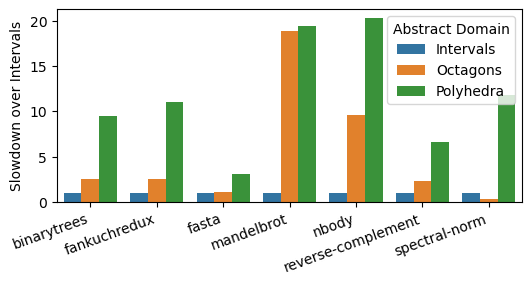

In [141]:
slowdown = df.groupby(by=['analysis','program']).mean().reset_index()
# speedup['speedup'] = speedup[speedup['analysis'] == 'Polyhedra']['time'] / speedup['time']

intervals = slowdown.loc[slowdown['analysis'] == 'Intervals']
intervals_slowdown = intervals['time'].values / slowdown[slowdown['analysis'] == 'Intervals']['time'].values

octagons = slowdown.loc[slowdown['analysis'] == 'Octagons']
octagons_slowdown = octagons['time'].values / slowdown[slowdown['analysis'] == 'Intervals']['time'].values

polyhedra = slowdown.loc[slowdown['analysis'] == 'Polyhedra']
polyhedra_slowdown = polyhedra['time'].values / slowdown[slowdown['analysis'] == 'Intervals']['time'].values

all_slowdown = np.concatenate([intervals_slowdown, octagons_slowdown, polyhedra_slowdown])
all_slowdown

slowdown['slowdown'] = all_slowdown

fig, ax = plt.subplots(figsize=(6, 2.5))
sns.barplot(slowdown, x = 'program', y = 'slowdown', hue = 'analysis', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_xlabel(None)
ax.set_ylabel("Slowdown over Intervals")
ax.legend_.set_title("Abstract Domain")
plt.savefig("benchmarksgame_slowdown_per_program.png",  bbox_inches="tight", dpi=300)

,analysis,program,run,env_size,byte_size,time
20,Polyhedra,spectral-norm,3.0,58.0,3.770,20.299621
19,Polyhedra,reverse-complement,3.0,51.0,8.096,1.541561
18,Polyhedra,nbody,3.0,147.0,24.108,52.084167
17,Polyhedra,mandelbrot,3.0,113.0,15.873,67.204160
16,Polyhedra,fasta,3.0,36.0,2.848,0.803107
15,Polyhedra,fankuchredux,3.0,51.0,3.723,4.023007
14,Polyhedra,binarytrees,3.0,47.0,21.956,8.205414
13,Octagons,spectral-norm,3.0,37.0,2.664,0.628726
12,Octagons,reverse-complement,3.0,50.0,5.100,0.530635
11,Octagons,nbody,3.0,147.0,43.512,24.720458


,env_size,byte_size
analysis,,
Intervals,70.571429,0.141143
Octagons,68.142857,12.690286
Polyhedra,71.857143,11.482000


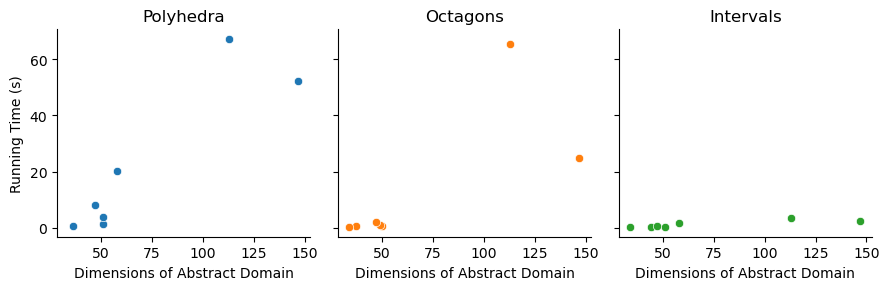

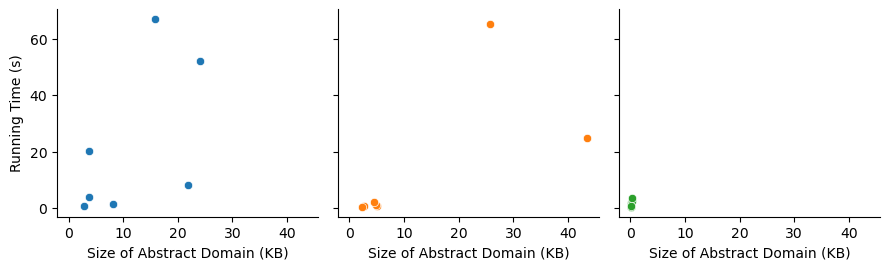

In [13]:
df = df.groupby(by=['analysis','program']).mean().reset_index()
df = df.reindex(index=df.index[::-1])
display(df)

display(df.groupby(by=['analysis'])[['env_size','byte_size']].mean())


# ax = sns.scatterplot(df, x = 'env_size', y = 'time', hue='analysis')
# ax.set_xlabel("Dimensions of Abstract Domain")
# ax.set_ylabel("Running Time (s)")

g = sns.FacetGrid(df, col='analysis', hue='analysis')
g.map_dataframe(sns.scatterplot, x = 'env_size', y = 'time')
for ax, title in zip(g.axes.flat,['Polyhedra', 'Octagons', 'Intervals']):
    ax.set_title(title)
    ax.set_xlabel("Dimensions of Abstract Domain")
    ax.set_ylabel("Running Time (s)")

plt.savefig("benchmarksgame_running_time_vs_env_size.png",  bbox_inches="tight", dpi=300)

# ax = sns.scatterplot(df, x = 'byte_size', y = 'time', hue='analysis')
# ax.set_xlabel("Size of Abstract Domain (KB)")
# ax.set_ylabel("Running Time (s)")

g = sns.FacetGrid(df, col='analysis', hue='analysis')
g.map_dataframe(sns.scatterplot, x = 'byte_size', y = 'time')
for ax, title in zip(g.axes.flat,['Polyhedra', 'Octagons', 'Intervals']):
    ax.set_title(None)
    ax.set_xlabel("Size of Abstract Domain (KB)")
    ax.set_ylabel("Running Time (s)")

plt.savefig("benchmarksgame_running_time_vs_byte_size.png",  bbox_inches="tight", dpi=300)